<a href="https://colab.research.google.com/github/knmp-04/restyle/blob/main/upcycling_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q rembg onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
pyt

In [2]:
import pandas as pd
import numpy as np
import cv2
import torch

from PIL import Image


from IPython.display import display
from google.colab import files



In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset(
    "fnauman/fashion-second-hand-front-only-rgb",
    split="train"
)

print(dataset)

README.md:   0%|          | 0.00/8.68k [00:00<?, ?B/s]

data/train-00000-of-00013.parquet: reconstructing file:   0%|          |  0.00B /  374MB            

data/train-00000-of-00013.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00013.parquet: reconstructing file:   0%|          |  0.00B /  173MB            

data/train-00001-of-00013.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/28248 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3390 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'brand', 'usage', 'condition', 'type', 'category', 'price', 'trend', 'colors', 'cut', 'pattern', 'season', 'text', 'pilling', 'damage', 'stains', 'holes', 'smell', 'material'],
    num_rows: 28248
})


In [4]:
df = dataset.to_pandas()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (28248, 19)


,image,brand,usage,condition,type,category,price,trend,colors,cut,pattern,season,text,pilling,damage,stains,holes,smell,material
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Soc (stadium),Reuse,5,Top,Ladies,<50,Sports,['Pink'],[],None,None,None,5,None,No,None,None,95%cotton 5%elastan
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Not Applicable,Export,1,T-shirt,Ladies,<50,No trend,"['Blue', 'White']",[],Floral print,None,None,2,None,Yes,None,None,33%cotton 67%polyester
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Xlnt (kappahl),Reuse,4,Dress,Ladies,<50,No trend,['Black'],[],None,None,None,4,None,No,None,None,100%viscose
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Not Applicable,Reuse,4,Sweater,Ladies,<50,No trend,['Red'],[],None,None,None,5,None,No,None,None,100%cotton
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Not Applicable,Export,3,Top,Ladies,<50,Sports,['Black'],[],None,None,None,5,None,Yes,None,None,100%polyester


In [5]:
df = df.drop(columns=["image"])

print("Dataset shape after removing image:", df.shape)

df.head()

Dataset shape after removing image: (28248, 18)


,brand,usage,condition,type,category,price,trend,colors,cut,pattern,season,text,pilling,damage,stains,holes,smell,material
0,Soc (stadium),Reuse,5,Top,Ladies,<50,Sports,['Pink'],[],None,None,None,5,None,No,None,None,95%cotton 5%elastan
1,Not Applicable,Export,1,T-shirt,Ladies,<50,No trend,"['Blue', 'White']",[],Floral print,None,None,2,None,Yes,None,None,33%cotton 67%polyester
2,Xlnt (kappahl),Reuse,4,Dress,Ladies,<50,No trend,['Black'],[],None,None,None,4,None,No,None,None,100%viscose
3,Not Applicable,Reuse,4,Sweater,Ladies,<50,No trend,['Red'],[],None,None,None,5,None,No,None,None,100%cotton
4,Not Applicable,Export,3,Top,Ladies,<50,Sports,['Black'],[],None,None,None,5,None,Yes,None,None,100%polyester


In [6]:
print(df.columns.tolist())

['brand', 'usage', 'condition', 'type', 'category', 'price', 'trend', 'colors', 'cut', 'pattern', 'season', 'text', 'pilling', 'damage', 'stains', 'holes', 'smell', 'material']


In [7]:
missing_values = df.isnull().sum()
keep_default_na=False
print("Missing Values:")
print(missing_values)

Missing Values:
brand            1
usage            0
condition        0
type             0
category         0
price            0
trend        23878
colors           0
cut              0
pattern      13865
season        6278
text         17535
pilling          0
damage       22662
stains       20070
holes        26883
smell        26623
material      1162
dtype: int64


In [9]:
# --------------------------------------------------
# FILL UNKNOWN CATEGORICAL INFORMATION
# --------------------------------------------------

unknown_columns = [
    "brand",
    "trend",
    "pattern",
    "season",
    "text",
    "material"
]

for column in unknown_columns:
    df[column] = df[column].fillna("Unknown")


# --------------------------------------------------
# FILL CONDITION / DAMAGE RELATED FEATURES
# --------------------------------------------------

condition_columns = [
    "damage",
    "stains",
    "holes",
    "smell"
]

for column in condition_columns:
    df[column] = df[column].fillna("None")


print("Missing values after handling:")

print(df.isnull().sum())

Missing values after handling:
brand        0
usage        0
condition    0
type         0
category     0
price        0
trend        0
colors       0
cut          0
pattern      0
season       0
text         0
pilling      0
damage       0
stains       0
holes        0
smell        0
material     0
dtype: int64


In [10]:
print(df.dtypes)

brand        object
usage        object
condition     int64
type         object
category     object
price        object
trend        object
colors       object
cut          object
pattern      object
season       object
text         object
pilling       int64
damage       object
stains       object
holes        object
smell        object
material     object
dtype: object


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 199


In [12]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (28248, 18)


In [13]:
df_clean.to_csv(
    "cleaned_second_hand_fashion.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [14]:
duplicates = df_clean.duplicated().sum()

print("Duplicate rows before removal:", duplicates)

df_clean = df_clean.drop_duplicates()

print("Duplicate rows after removal:", df_clean.duplicated().sum())

print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows before removal: 199
Duplicate rows after removal: 0
Shape after removing duplicates: (28049, 18)


In [15]:
selected_columns = [
    "type",
    "colors",
    "condition",
    "trend",
    "pattern",
    "pilling",
    "damage",
    "stains",
    "holes",
    "smell",
    "material",
    "usage"
]

df = df[selected_columns].copy()

print("New dataset shape:", df.shape)

df.head()

New dataset shape: (28248, 12)


,type,colors,condition,trend,pattern,pilling,damage,stains,holes,smell,material,usage
0,Top,['Pink'],5,Sports,Unknown,5,None,No,None,None,95%cotton 5%elastan,Reuse
1,T-shirt,"['Blue', 'White']",1,No trend,Floral print,2,None,Yes,None,None,33%cotton 67%polyester,Export
2,Dress,['Black'],4,No trend,Unknown,4,None,No,None,None,100%viscose,Reuse
3,Sweater,['Red'],4,No trend,Unknown,5,None,No,None,None,100%cotton,Reuse
4,Top,['Black'],3,Sports,Unknown,5,None,Yes,None,None,100%polyester,Export


In [16]:
for column in df_clean.columns:

    print("\n" + "=" * 60)
    print("COLUMN:", column)

    print("\nUnique values:", df_clean[column].nunique())

    print("\nTop values:")
    print(df_clean[column].value_counts().head(15))


COLUMN: brand

Unique values: 4671

Top values:
brand
H&m               2889
Missing           2762
Lindex            1276
Not Applicable    1027
Kappahl            851
Gina Tricot        638
Zara               465
Lager 157          436
Isolde             320
Indiska            276
Dressman           255
Shein              233
Esprit             222
Cubus              216
Vero Moda          198
Name: count, dtype: int64

COLUMN: usage

Unique values: 7

Top values:
usage
Reuse              17113
Export              8654
Recycle             1960
Remake               146
Repair               116
Energy Recovery       59
Rcycle                 1
Name: count, dtype: int64

COLUMN: condition

Unique values: 5

Top values:
condition
3    8384
5    7245
4    6987
2    4505
1     928
Name: count, dtype: int64

COLUMN: type

Unique values: 30

Top values:
type
Top         3783
T-shirt     3014
Trousers    2862
Dress       2533
Sweater     2377
Blouse      1928
Shirt       1902
Jeans       137

In [17]:
relevant_columns = [
    "type",
    "colors",
    "condition",
    "pattern",
    "pilling",
    "damage",
    "stains",
    "holes",
    "smell",
    "material",
    "usage"
]

for column in relevant_columns:

    print("\n" + "=" * 60)
    print("COLUMN:", column)
    print(df_clean[column].value_counts())


COLUMN: type
type
Top                3783
T-shirt            3014
Trousers           2862
Dress              2533
Sweater            2377
Blouse             1928
Shirt              1902
Jeans              1370
Skirt              1116
Tank Top           1048
Cardigan            950
Shorts              896
Jacket              832
Blazer              605
Hoodie              513
Tights              489
Vest                354
Pajamas             299
Outerwear           257
Training Top        211
Tunic               174
Winter Jacket       153
Night Gown          115
Jacker               57
Rain Jacket          45
Denim Jacket         42
Rain Trousers        39
Robe                 39
Winter Trousers      35
Nightgown            11
Name: count, dtype: int64

COLUMN: colors
colors
['Black']                                          3970
['Blue']                                           3279
['White']                                          2127
['Grey']                                    

In [18]:
print(df_clean["usage"].value_counts())

usage
Reuse              17113
Export              8654
Recycle             1960
Remake               146
Repair               116
Energy Recovery       59
Rcycle                 1
Name: count, dtype: int64


In [19]:
usage_percentage = (
    df_clean["usage"]
    .value_counts(normalize=True)
    * 100
)

print(usage_percentage.round(2))

usage
Reuse              61.01
Export             30.85
Recycle             6.99
Remake              0.52
Repair              0.41
Energy Recovery     0.21
Rcycle              0.00
Name: proportion, dtype: float64


In [20]:
ml_columns = [
    "type",
    "colors",
    "condition",
    "pattern",
    "pilling",
    "damage",
    "stains",
    "holes",
    "smell",
    "material",
    "usage"
]

ml_df = df_clean[ml_columns].copy()

print("ML Dataset Shape:", ml_df.shape)

ml_df.head()

ML Dataset Shape: (28049, 11)


,type,colors,condition,pattern,pilling,damage,stains,holes,smell,material,usage
0,Top,['Pink'],5,Unknown,5,None,No,None,None,95%cotton 5%elastan,Reuse
1,T-shirt,"['Blue', 'White']",1,Floral print,2,None,Yes,None,None,33%cotton 67%polyester,Export
2,Dress,['Black'],4,Unknown,4,None,No,None,None,100%viscose,Reuse
3,Sweater,['Red'],4,Unknown,5,None,No,None,None,100%cotton,Reuse
4,Top,['Black'],3,Unknown,5,None,Yes,None,None,100%polyester,Export


In [21]:
# Create a copy
feature_df = ml_df.copy()


# Function to identify whether a problem exists
def has_problem(value):

    value = str(value).strip().lower()

    no_problem_values = [
        "none",
        "unknown",
        "nan",
        "",
        "no"
    ]

    if value in no_problem_values:
        return 0

    return 1


# Create new engineered features

feature_df["has_damage"] = (
    feature_df["damage"].apply(has_problem)
)

feature_df["has_stains"] = (
    feature_df["stains"].apply(has_problem)
)

feature_df["has_holes"] = (
    feature_df["holes"].apply(has_problem)
)

feature_df["has_smell"] = (
    feature_df["smell"].apply(has_problem)
)

feature_df["has_pilling"] = (
    feature_df["pilling"].apply(has_problem)
)


print(feature_df[
    [
        "damage",
        "has_damage",
        "stains",
        "has_stains",
        "holes",
        "has_holes"
    ]
].head(10))

  damage  has_damage stains  has_stains holes  has_holes
0   None           0     No           0  None          0
1   None           0    Yes           1  None          0
2   None           0     No           0  None          0
3   None           0     No           0  None          0
4   None           0    Yes           1  None          0
5   None           0    Yes           1  None          0
6   None           0     No           0  None          0
7   None           0     No           0  None          0
8   None           0     No           0  None          0
9   None           0     No           0  None          0


In [22]:
issue_columns = [
    "has_damage",
    "has_stains",
    "has_holes",
    "has_smell",
    "has_pilling"
]

feature_df["issue_score"] = (
    feature_df[issue_columns].sum(axis=1)
)

print(
    feature_df["issue_score"]
    .value_counts()
    .sort_index()
)

issue_score
1    17474
2     6325
3     3824
4      404
5       22
Name: count, dtype: int64


In [23]:
issue_usage = pd.crosstab(
    feature_df["issue_score"],
    feature_df["usage"],
    normalize="index"
) * 100

print(issue_usage.round(2))

usage        Energy Recovery  Export  Rcycle  Recycle  Remake  Repair  Reuse
issue_score                                                                 
1                       0.07   15.01    0.01     3.04    0.21    0.21  81.45
2                       0.22   48.90    0.00    12.85    0.82    1.06  36.14
3                       0.71   68.70    0.00    14.23    1.33    0.29  14.75
4                       1.24   73.02    0.00    17.08    1.49    0.25   6.93
5                       0.00   72.73    0.00    13.64    0.00    4.55   9.09


In [24]:
X = feature_df.drop(columns=["usage"])

In [25]:
y = feature_df["usage"]

In [26]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.unique())

X Shape: (28049, 16)
y Shape: (28049,)

Input Features:
['type', 'colors', 'condition', 'pattern', 'pilling', 'damage', 'stains', 'holes', 'smell', 'material', 'has_damage', 'has_stains', 'has_holes', 'has_smell', 'has_pilling', 'issue_score']

Target Classes:
['Reuse' 'Export' 'Recycle' 'Repair' 'Remake' 'Energy Recovery' 'Rcycle']


In [27]:
# Check class frequencies
class_counts = y.value_counts()

print("Class counts:")
print(class_counts)

# Keep only classes with at least 2 samples
valid_classes = class_counts[
    class_counts >= 2
].index

# Filter the dataset
feature_df = feature_df[
    feature_df["usage"].isin(valid_classes)
].copy()

# Create X and y again
X = feature_df.drop(columns=["usage"])
y = feature_df["usage"]

print("\nDataset shape after removing extremely rare classes:")
print(feature_df.shape)

print("\nUpdated class distribution:")
print(y.value_counts())

Class counts:
usage
Reuse              17113
Export              8654
Recycle             1960
Remake               146
Repair               116
Energy Recovery       59
Rcycle                 1
Name: count, dtype: int64

Dataset shape after removing extremely rare classes:
(28048, 17)

Updated class distribution:
usage
Reuse              17113
Export              8654
Recycle             1960
Remake               146
Repair               116
Energy Recovery       59
Name: count, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Data: (22438, 16)
Testing Data: (5610, 16)

Training Target Distribution:
usage
Reuse              61.012568
Export             30.853909
Recycle             6.988145
Remake              0.521437
Repair              0.414475
Energy Recovery     0.209466
Name: proportion, dtype: float64

Testing Target Distribution:
usage
Reuse              61.016043
Export             30.855615
Recycle             6.987522
Remake              0.516934
Repair              0.409982
Energy Recovery     0.213904
Name: proportion, dtype: float64


In [29]:
# Identify categorical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Identify numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['type', 'colors', 'pattern', 'damage', 'stains', 'holes', 'smell', 'material']

Numerical Features:
['condition', 'pilling', 'has_damage', 'has_stains', 'has_holes', 'has_smell', 'has_pilling', 'issue_score']


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create the OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [31]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Training data shape after encoding:")
print(X_train_encoded.shape)

print("\nTesting data shape after encoding:")
print(X_test_encoded.shape)

Training data shape after encoding:
(22438, 7600)

Testing data shape after encoding:
(5610, 7600)


In [32]:
print("First 5 encoded rows:")

print(
    X_train_encoded[:5]
)

First 5 encoded rows:
[[0. 0. 0. ... 0. 1. 3.]
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 1. 2.]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Temporary model for feature selection
feature_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

feature_selector.fit(
    X_train_encoded,
    y_train
)

print("Feature selection model trained successfully!")

Feature selection model trained successfully!


In [34]:
# Get the names of all encoded features
encoded_feature_names = preprocessor.get_feature_names_out()

print("Total encoded features:")
print(len(encoded_feature_names))

print("\nFirst 20 encoded features:")
print(encoded_feature_names[:20])

Total encoded features:
7600

First 20 encoded features:
['categorical__type_Blazer' 'categorical__type_Blouse'
 'categorical__type_Cardigan' 'categorical__type_Denim Jacket'
 'categorical__type_Dress' 'categorical__type_Hoodie'
 'categorical__type_Jacker' 'categorical__type_Jacket'
 'categorical__type_Jeans' 'categorical__type_Night Gown'
 'categorical__type_Nightgown' 'categorical__type_Outerwear'
 'categorical__type_Pajamas' 'categorical__type_Rain Jacket'
 'categorical__type_Rain Trousers' 'categorical__type_Robe'
 'categorical__type_Shirt' 'categorical__type_Shorts'
 'categorical__type_Skirt' 'categorical__type_Sweater']


In [35]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": feature_selector.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
7592,remainder__condition,0.169825
7593,remainder__pilling,0.078083
7599,remainder__issue_score,0.046527
7595,remainder__has_stains,0.035893
3343,categorical__stains_None,0.035554
2384,categorical__damage_None,0.023068
7594,remainder__has_damage,0.022615
3340,categorical__stains_Major,0.020245
3341,categorical__stains_Minor,0.013235
3391,categorical__material_100% Cotton,0.012495


In [36]:
important_features = feature_importance[
    feature_importance["importance"] > 0
]

print("Total encoded features:", len(feature_importance))
print("Features with importance greater than 0:", len(important_features))

important_features.head(20)

Total encoded features: 7600
Features with importance greater than 0: 7599


,feature,importance
7592,remainder__condition,0.169825
7593,remainder__pilling,0.078083
7599,remainder__issue_score,0.046527
7595,remainder__has_stains,0.035893
3343,categorical__stains_None,0.035554
2384,categorical__damage_None,0.023068
7594,remainder__has_damage,0.022615
3340,categorical__stains_Major,0.020245
3341,categorical__stains_Minor,0.013235
3391,categorical__material_100% Cotton,0.012495


In [37]:
selected_feature_indices = [
    feature_importance.index.get_loc(index)
    for index in important_features.index
]

In [38]:
selected_feature_indices = (
    feature_importance["importance"] > 0
).values

print("Selected features:", selected_feature_indices.sum())

Selected features: 7599


In [39]:
X_train_selected = X_train_encoded[
    :,
    selected_feature_indices
]

X_test_selected = X_test_encoded[
    :,
    selected_feature_indices
]

print("Training shape after feature selection:")
print(X_train_selected.shape)

print("Testing shape after feature selection:")
print(X_test_selected.shape)

Training shape after feature selection:
(22438, 7599)
Testing shape after feature selection:
(5610, 7599)


In [40]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")

# Train the model
rf_model.fit(
    X_train_selected,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [42]:
# Predict on training data
y_train_pred_rf = rf_model.predict(
    X_train_selected
)

# Predict on testing data
y_test_pred_rf = rf_model.predict(
    X_test_selected
)

print("Predictions completed!")

Predictions completed!


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Training accuracy
rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

# Testing accuracy
rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_rf
)

# Precision
rf_precision = precision_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

# Recall
rf_recall = recall_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

# F1 Score
rf_f1 = f1_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(
    "Training Accuracy:",
    round(rf_train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy:",
    round(rf_test_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(rf_precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(rf_recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(rf_f1 * 100, 2),
    "%"
)

RANDOM FOREST RESULTS
Training Accuracy: 99.11 %
Testing Accuracy: 83.44 %
Precision: 82.06 %
Recall: 83.44 %
F1 Score: 82.08 %


In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

Energy Recovery       0.00      0.00      0.00        12
         Export       0.75      0.80      0.78      1731
        Recycle       0.60      0.25      0.35       392
         Remake       0.23      0.10      0.14        29
         Repair       0.67      0.09      0.15        23
          Reuse       0.89      0.93      0.91      3423

       accuracy                           0.83      5610
      macro avg       0.52      0.36      0.39      5610
   weighted avg       0.82      0.83      0.82      5610



In [45]:
rf_results = {
    "Algorithm": "Random Forest",
    "Train Accuracy": rf_train_accuracy,
    "Test Accuracy": rf_test_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
}

print(rf_results)

{'Algorithm': 'Random Forest', 'Train Accuracy': 0.9911311168553347, 'Test Accuracy': 0.8344028520499108, 'Precision': 0.8206470172098819, 'Recall': 0.8344028520499108, 'F1 Score': 0.8208428267122257}


In [46]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Training Gradient Boosting...")

# Train the model
gb_model.fit(
    X_train_selected,
    y_train
)

print("Gradient Boosting training completed!")

Training Gradient Boosting...
Gradient Boosting training completed!


In [47]:
# Training predictions
y_train_pred_gb = gb_model.predict(
    X_train_selected
)

# Testing predictions
y_test_pred_gb = gb_model.predict(
    X_test_selected
)

print("Gradient Boosting predictions completed!")

Gradient Boosting predictions completed!


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Training accuracy
gb_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_gb
)

# Testing accuracy
gb_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_gb
)

# Precision
gb_precision = precision_score(
    y_test,
    y_test_pred_gb,
    average="weighted",
    zero_division=0
)

# Recall
gb_recall = recall_score(
    y_test,
    y_test_pred_gb,
    average="weighted",
    zero_division=0
)

# F1 Score
gb_f1 = f1_score(
    y_test,
    y_test_pred_gb,
    average="weighted",
    zero_division=0
)

print("=" * 50)
print("GRADIENT BOOSTING RESULTS")
print("=" * 50)

print(
    "Training Accuracy:",
    round(gb_train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy:",
    round(gb_test_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(gb_precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(gb_recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(gb_f1 * 100, 2),
    "%"
)

GRADIENT BOOSTING RESULTS
Training Accuracy: 85.81 %
Testing Accuracy: 84.6 %
Precision: 83.84 %
Recall: 84.6 %
F1 Score: 83.7 %


In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred_gb,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

Energy Recovery       0.18      0.25      0.21        12
         Export       0.77      0.81      0.79      1731
        Recycle       0.73      0.35      0.48       392
         Remake       0.08      0.03      0.05        29
         Repair       0.17      0.04      0.07        23
          Reuse       0.90      0.93      0.92      3423

       accuracy                           0.85      5610
      macro avg       0.47      0.40      0.42      5610
   weighted avg       0.84      0.85      0.84      5610



In [50]:
gb_results = {
    "Algorithm": "Gradient Boosting",
    "Train Accuracy": gb_train_accuracy,
    "Test Accuracy": gb_test_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1 Score": gb_f1
}

print(gb_results)

{'Algorithm': 'Gradient Boosting', 'Train Accuracy': 0.8580978696853552, 'Test Accuracy': 0.8459893048128342, 'Precision': 0.8384351561985585, 'Recall': 0.8459893048128342, 'F1 Score': 0.8370483590474247}


In [51]:
  comparison_df = pd.DataFrame([
    rf_results,
    gb_results
])

# Convert decimal values into percentages
metric_columns = [
    "Train Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

comparison_df[metric_columns] = (
    comparison_df[metric_columns] * 100
)

comparison_df.round(2)

,Algorithm,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Random Forest,99.11,83.44,82.06,83.44,82.08
1,Gradient Boosting,85.81,84.60,83.84,84.60,83.70


In [52]:
best_algorithm = comparison_df.loc[
    comparison_df["F1 Score"].idxmax(),
    "Algorithm"
]

print("Best performing algorithm:", best_algorithm)

Best performing algorithm: Gradient Boosting


In [53]:
import joblib

# Save Random Forest
joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

# Save Gradient Boosting
joblib.dump(
    gb_model,
    "gradient_boosting_model.pkl"
)

# Save the encoder/preprocessor
joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

# Save feature selection mask
joblib.dump(
    selected_feature_indices,
    "selected_feature_indices.pkl"
)

# Save the original feature column names
joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

print("All ML files saved successfully!")

All ML files saved successfully!


In [54]:
import sklearn

print(sklearn.__version__)

1.6.1


Upload a clothing image:


Saving OIP (2).jpg to OIP (2) (1).jpg
Original image:


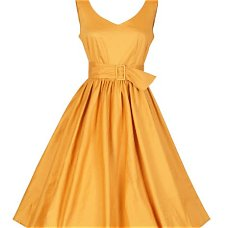

In [78]:
print("Upload a clothing image:")

uploaded_image = files.upload()

image_file = list(uploaded_image.keys())[0]

image = Image.open(image_file).convert("RGB")

print("Original image:")
display(image)

  0%|                                              | 0.00/1.02G [00:00<?, ?B/s]

Background removed:


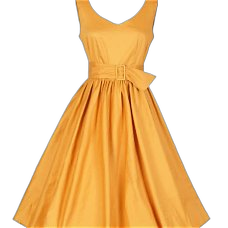

In [79]:
output = remove(image)

print("Background removed:")
display(output)

In [80]:
output.save("/content/background_removed.png")

In [81]:
model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = clip_model.to(device)

print("Using:", device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Using: cpu


In [82]:
clothing_labels = [
    "a t-shirt",
    "a shirt",
    "a pair of jeans",
    "a dress",
    "a jacket",
    "a skirt",
    "a hoodie",
    "a sweater",
    "a kurta",
    "a saree"
]

In [83]:
def detect_clothing_type(image):

    inputs = clip_processor(
        text=clothing_labels,
        images=image,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = clip_model(**inputs)

    probabilities = outputs.logits_per_image.softmax(dim=1)

    best_index = probabilities.argmax().item()

    category = clothing_labels[best_index]
    confidence = probabilities[0][best_index].item() * 100

    return category, confidence

In [84]:
category_mapping = {
    "a t-shirt": "T-shirt",
    "a shirt": "Shirt",
    "a pair of jeans": "Jeans",
    "a dress": "Dress",
    "a jacket": "Jacket",
    "a skirt": "Skirt",
    "a hoodie": "Hoodie",
    "a sweater": "Sweater",
    "a kurta": "Kurta",
    "a saree": "Saree"
}

In [85]:
detected_category, category_confidence = detect_clothing_type(output)

csv_category = category_mapping[detected_category]

print("Detected category:", csv_category)
print("Confidence:", round(category_confidence, 2), "%")

Detected category: Dress
Confidence: 98.94 %


In [92]:
import numpy as np
import cv2
from PIL import Image

def detect_dominant_colour(image):

    # Convert PIL image to RGBA
    image_rgba = image.convert("RGBA")

    # Convert to NumPy
    img = np.array(image_rgba)

    # Separate RGB and Alpha
    rgb = img[:, :, :3]
    alpha = img[:, :, 3]

    # Keep only pixels belonging to the clothing
    # Alpha > 50 removes transparent background
    mask = alpha > 50

    pixels = rgb[mask]

    # Check if enough clothing pixels were found
    if len(pixels) < 100:
        print("Warning: Not enough clothing pixels detected.")
        return "Unknown", None

    # Convert RGB pixels to HSV
    hsv_pixels = cv2.cvtColor(
        pixels.reshape(-1, 1, 3).astype(np.uint8),
        cv2.COLOR_RGB2HSV
    ).reshape(-1, 3)

    # Remove very bright/very dark extreme pixels
    # These are often highlights or shadows
    valid = ~(
        ((hsv_pixels[:, 2] > 245) & (hsv_pixels[:, 1] < 30)) |
        ((hsv_pixels[:, 2] < 15))
    )

    hsv_pixels = hsv_pixels[valid]
    pixels = pixels[valid]

    if len(pixels) < 100:
        return "Unknown", None

    # K-Means
    pixels_float = np.float32(pixels)

    criteria = (
        cv2.TERM_CRITERIA_EPS +
        cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    k = 5

    _, labels, centers = cv2.kmeans(
        pixels_float,
        k,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS
    )

    # Find largest cluster
    counts = np.bincount(labels.flatten())

    dominant_index = np.argmax(counts)

    dominant_rgb = centers[dominant_index].astype(int)

    # Convert dominant RGB to HSV
    dominant_rgb_uint8 = np.uint8(
        [[dominant_rgb]]
    )

    dominant_hsv = cv2.cvtColor(
        dominant_rgb_uint8,
        cv2.COLOR_RGB2HSV
    )[0][0]

    return dominant_rgb, dominant_hsv

In [108]:
def classify_colour(rgb, hsv):

    if rgb is None or hsv is None:
        return "Unknown"

    r, g, b = rgb
    h, s, v = hsv

    # BLACK
    if v < 45:
        return "Black"

    # WHITE
    if v > 210 and s < 30:
        return "White"

    # GREY
    if s < 35 and 45 <= v <= 210:
        return "Grey"

    # BEIGE
    if (
        15 <= h <= 30
        and 20 <= s <= 100
        and v > 150
    ):
        return "Beige"

    # BROWN
    if (
        5 <= h < 20
        and s > 70
        and v < 180
    ):
        return "Brown"

    # RED
    if h < 10 or h >= 170:
        return "Red"

    # YELLOW
    if 20 <= h < 40:
        return "Yellow"

    # GREEN
    if 40 <= h < 85:
        return "Green"

    # NAVY
    if (
        90 <= h <= 130
        and s > 100
        and v < 100
    ):
        return "Navy"

    # BLUE
    if 85 <= h <= 135:
        return "Blue"

    # PINK
    if 150 <= h < 175:
        return "Pink"

    return "Multicolor"

In [109]:
dominant_rgb, dominant_hsv = detect_dominant_colour(output)

detected_colour = classify_colour(
    dominant_rgb,
    dominant_hsv
)

print("Dominant RGB:", dominant_rgb)
print("Dominant HSV:", dominant_hsv)
print("Detected Colour:", detected_colour)

Dominant RGB: [234 161  66]
Dominant HSV: [ 17 183 234]
Detected Colour: Multicolor


Original Image:


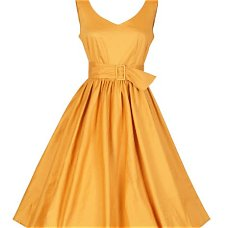


Background Removed:


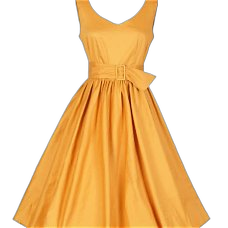

In [110]:
print("Original Image:")
display(image)

print("\nBackground Removed:")
display(output)

In [111]:
def show_detected_colour(rgb):

    if rgb is None:
        return

    swatch = np.zeros((150, 300, 3), dtype=np.uint8)

    swatch[:, :] = rgb

    display(
        Image.fromarray(swatch)
    )

    print("Detected RGB:", rgb)

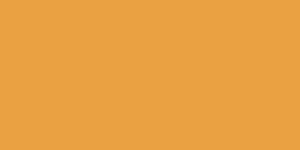

Detected RGB: [234 161  66]
Detected Colour: Multicolor


In [112]:
show_detected_colour(dominant_rgb)

print("Detected Colour:", detected_colour)

In [113]:
pattern_labels = [
    "a plain solid colour clothing",
    "striped clothing",
    "checked or plaid clothing",
    "floral clothing",
    "polka dot clothing",
    "graphic printed clothing",
    "animal print clothing",
    "abstract printed clothing"
]

In [114]:
def detect_pattern(image):

    inputs = clip_processor(
        text=pattern_labels,
        images=image,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = clip_model(**inputs)

    probabilities = outputs.logits_per_image.softmax(dim=1)

    best_index = probabilities.argmax().item()

    pattern = pattern_labels[best_index]
    confidence = probabilities[0][best_index].item() * 100

    return pattern, confidence

In [115]:
detected_pattern, pattern_confidence = detect_pattern(output)

print("Pattern:", detected_pattern)
print("Confidence:", round(pattern_confidence, 2), "%")

Pattern: a plain solid colour clothing
Confidence: 91.51 %


In [117]:
print("Enter additional clothing information.")

material = input(
    "Material (e.g. Denim, Cotton, Polyester): "
)

condition = input(
    "Condition (e.g. Excellent, Good, Fair, Poor): "
)

damage_location = input(
    "Damage location (e.g. None, Bottom, Knee, Sleeve): "
)

damage_severity = input(
    "Damage severity (e.g. None, Minor, Moderate, Major): "
)

Enter additional clothing information.
Material (e.g. Denim, Cotton, Polyester): cotton
Condition (e.g. Excellent, Good, Fair, Poor): good
Damage location (e.g. None, Bottom, Knee, Sleeve): none
Damage severity (e.g. None, Minor, Moderate, Major): none


In [118]:
clothing_profile = {
    "clothing_type": csv_category,
    "colour": detected_colour,
    "pattern": detected_pattern,
    "material": material,
    "condition": condition,
    "damage_location": damage_location,
    "damage_severity": damage_severity
}

print("\nDetected Clothing Profile")
print("=" * 40)

for key, value in clothing_profile.items():
    print(f"{key}: {value}")



Detected Clothing Profile
clothing_type: Dress
colour: Multicolor
pattern: a plain solid colour clothing
material: cotton
condition: good
damage_location: none
damage_severity: none


In [126]:
features = [
    "clothing_type",
    "colour",
    "condition",
    "damage_location",
    "damage_severity",
    "stain_severity",
    "hole_severity",
    "repair_status",
    "style",
    "material"
]

target = "recommended_action"

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['clothing_type', 'colour', 'condition', 'damage_location', 'damage_severity', 'stain_severity', 'hole_severity', 'repair_status', 'style', 'material']

Target:
recommended_action


In [128]:
print("Number of recommendation classes:")
print(y.nunique())

print("\nRecommendation distribution:")
print(y.value_counts())

Number of recommendation classes:
35

Recommendation distribution:
recommended_action
Convert into a sleeveless vest                                1622
Convert into a reusable fabric tote                           1622
Shorten the dress and refinish the hem                         811
Recover usable fabric for a skirt or accessories               811
Redesign into a sleeveless dress                               811
Reuse usable denim sections for an accessory                   811
Convert into denim shorts                                      811
Create denim patchwork                                         811
Add a fabric patch or decorative panel                         811
Recover intact fabric for accessories                          811
Apply visible patches                                          811
Convert into shorter leggings                                  811
Recover fabric for small textile accessories                   811
Create a small denim accessory from unused 

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 24000
Testing records: 6000


In [138]:
categorical_features = features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [139]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [140]:
print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [141]:
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest Results
----------------------
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %


In [143]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Preprocessing
preprocessor_gb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), features)
    ]
)

# Gradient Boosting model
gb_model = Pipeline([
    ("preprocessor", preprocessor_gb),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

print("Training Gradient Boosting...")

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed!")

Training Gradient Boosting...
Gradient Boosting training completed!


In [144]:
gb_predictions = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

print("Gradient Boosting Results")
print("--------------------------")
print("Accuracy :", round(gb_accuracy * 100, 2), "%")
print("Precision:", round(gb_precision * 100, 2), "%")
print("Recall   :", round(gb_recall * 100, 2), "%")
print("F1 Score :", round(gb_f1 * 100, 2), "%")

Gradient Boosting Results
--------------------------
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %


In [145]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],

    "Gradient Boosting": [
        gb_accuracy,
        gb_precision,
        gb_recall,
        gb_f1
    ]
})

comparison

,Metric,Random Forest,Gradient Boosting
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1 Score,1.0,1.0


In [146]:
rf_parameters = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_parameters,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Tuning Random Forest...")

rf_grid.fit(
    X_train,
    y_train
)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

Tuning Random Forest...
Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [ ]:
gb_parameters = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_parameters,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Tuning Gradient Boosting...")

gb_grid.fit(
    X_train,
    y_train
)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

In [ ]:
rf_best = rf_grid.best_estimator_
gb_best = gb_grid.best_estimator_

rf_tuned_predictions = rf_best.predict(X_test)
gb_tuned_predictions = gb_best.predict(X_test)

In [ ]:
rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_predictions
)

rf_tuned_precision = precision_score(
    y_test,
    rf_tuned_predictions,
    average="weighted",
    zero_division=0
)

rf_tuned_recall = recall_score(
    y_test,
    rf_tuned_predictions,
    average="weighted",
    zero_division=0
)

rf_tuned_f1 = f1_score(
    y_test,
    rf_tuned_predictions,
    average="weighted",
    zero_division=0
)


gb_tuned_accuracy = accuracy_score(
    y_test,
    gb_tuned_predictions
)

gb_tuned_precision = precision_score(
    y_test,
    gb_tuned_predictions,
    average="weighted",
    zero_division=0
)

gb_tuned_recall = recall_score(
    y_test,
    gb_tuned_predictions,
    average="weighted",
    zero_division=0
)

gb_tuned_f1 = f1_score(
    y_test,
    gb_tuned_predictions,
    average="weighted",
    zero_division=0
)

In [ ]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Random Forest": [
        rf_tuned_accuracy,
        rf_tuned_precision,
        rf_tuned_recall,
        rf_tuned_f1
    ],

    "Gradient Boosting": [
        gb_tuned_accuracy,
        gb_tuned_precision,
        gb_tuned_recall,
        gb_tuned_f1
    ]
})

final_comparison

In [ ]:
if rf_tuned_f1 >= gb_tuned_f1:

    best_model = rf_best
    best_model_name = "Random Forest"
    best_score = rf_tuned_f1

else:

    best_model = gb_best
    best_model_name = "Gradient Boosting"
    best_score = gb_tuned_f1

print("Best Model:", best_model_name)
print("F1 Score:", round(best_score * 100, 2), "%")

In [119]:
def generate_recommendations(profile, top_n=3):

    data = df.copy()

    # Clean text columns
    columns = [
        "clothing_type",
        "colour",
        "condition",
        "damage_location",
        "damage_severity",
        "material",
        "style"
    ]

    for column in columns:
        data[column] = (
            data[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    # Convert input values to lowercase
    clothing_type = profile["clothing_type"].strip().lower()
    colour = profile["colour"].strip().lower()
    material = profile["material"].strip().lower()
    condition = profile["condition"].strip().lower()
    damage_location = profile["damage_location"].strip().lower()
    damage_severity = profile["damage_severity"].strip().lower()

    # Start with all records
    data["match_score"] = 0

    # Clothing type is the most important feature
    data["match_score"] += (
        data["clothing_type"] == clothing_type
    ) * 30

    # Colour
    data["match_score"] += (
        data["colour"] == colour
    ) * 15

    # Material
    data["match_score"] += (
        data["material"] == material
    ) * 15

    # Condition
    data["match_score"] += (
        data["condition"] == condition
    ) * 10

    # Damage location
    data["match_score"] += (
        data["damage_location"] == damage_location
    ) * 15

    # Damage severity
    data["match_score"] += (
        data["damage_severity"] == damage_severity
    ) * 15

    # Keep records that at least match the clothing type
    data = data[
        data["clothing_type"] == clothing_type
    ].copy()

    if data.empty:
        return pd.DataFrame()

    # Sort by matching score
    data = data.sort_values(
        by="match_score",
        ascending=False
    )

    # Keep only the best recommendation for each action
    data = data.drop_duplicates(
        subset=["recommended_action"]
    )

    return data.head(top_n)

In [120]:
recommendations = generate_recommendations(
    clothing_profile,
    top_n=3
)

recommendations[
    [
        "recommended_action",
        "upcycling_method",
        "difficulty",
        "reason",
        "required_materials",
        "estimated_time_minutes",
        "match_score"
    ]
]

,recommended_action,upcycling_method,difficulty,reason,required_materials,estimated_time_minutes,match_score
29357,Redesign the silhouette through length alteration,Silhouette redesign,Medium,A usable garment can receive a new silhouette ...,"Scissors, measuring tape and sewing supplies",75,100
17835,Redesign into a sleeveless dress,Sleeve removal,Medium,Removing damaged sleeves can preserve the dres...,"Scissors, thread, needle or sewing machine",75,45
17834,Shorten the dress and refinish the hem,Length alteration,Easy,A damaged lower edge can be removed while reta...,"Scissors, measuring tape and sewing tools",60,45


In [121]:
def display_final_recommendations(
    profile,
    recommendations
):

    print("\n")
    print("=" * 70)
    print("                    RESTYLE")
    print("             UPCYCLING RECOMMENDATIONS")
    print("=" * 70)

    print("\nCLOTHING ANALYSIS")
    print("-" * 70)

    print(f"Category       : {profile['clothing_type']}")
    print(f"Colour         : {profile['colour']}")
    print(f"Pattern        : {profile['pattern']}")
    print(f"Material       : {profile['material']}")
    print(f"Condition      : {profile['condition']}")
    print(f"Damage         : {profile['damage_location']}")
    print(f"Damage Severity: {profile['damage_severity']}")

    print("\nTOP RECOMMENDATIONS")
    print("-" * 70)

    for i, (_, row) in enumerate(
        recommendations.iterrows(),
        start=1
    ):

        print(f"\n{i}. {row['recommended_action']}")

        print(
            f"   Match Score : {row['match_score']}/100"
        )

        print(
            f"   Method      : {row['upcycling_method']}"
        )

        print(
            f"   Difficulty  : {row['difficulty']}"
        )

        print(
            f"   Reason      : {row['reason']}"
        )

        print(
            f"   Materials   : {row['required_materials']}"
        )

        print(
            f"   Time        : "
            f"{row['estimated_time_minutes']} minutes"
        )

    print("\n" + "=" * 70)

In [122]:
display_final_recommendations(
    clothing_profile,
    recommendations
)



                    RESTYLE
             UPCYCLING RECOMMENDATIONS

CLOTHING ANALYSIS
----------------------------------------------------------------------
Category       : Dress
Colour         : Multicolor
Pattern        : a plain solid colour clothing
Material       : cotton
Condition      : good
Damage         : none
Damage Severity: none

TOP RECOMMENDATIONS
----------------------------------------------------------------------

1. Redesign the silhouette through length alteration
   Match Score : 100/100
   Method      : Silhouette redesign
   Difficulty  : Medium
   Reason      : A usable garment can receive a new silhouette instead of being discarded.
   Materials   : Scissors, measuring tape and sewing supplies
   Time        : 75 minutes

2. Redesign into a sleeveless dress
   Match Score : 45/100
   Method      : Sleeve removal
   Difficulty  : Medium
   Reason      : Removing damaged sleeves can preserve the dress body.
   Materials   : Scissors, thread, needle or sewing 

In [21]:
material = input(
    "Material (Cotton/Denim/Polyester/Wool/Silk/Other): "
)

Material (Cotton/Denim/Polyester/Wool/Silk/Other): cotton


In [23]:
def recommend_upcycling(
    clothing_type,
    colour,
    condition,
    damage_location,
    damage_severity,
    stain_severity,
    hole_severity,
    repair_status,
    style,
    material,
    top_n=3
):

    data = df_recommendations.copy()

    # Make sure all values are treated as text
    columns_to_check = [
        "clothing_type",
        "colour",
        "condition",
        "damage_location",
        "damage_severity",
        "stain_severity",
        "hole_severity",
        "repair_status",
        "style",
        "material"
    ]

    for col in columns_to_check:
        data[col] = data[col].fillna("").astype(str).str.strip()

    # ------------------------------------------------
    # 1. Filter by clothing type
    # ------------------------------------------------
    data = data[
        data["clothing_type"].str.lower()
        == clothing_type.strip().lower()
    ].copy()

    if data.empty:
        print("No recommendations found for:", clothing_type)
        return pd.DataFrame()

    # ------------------------------------------------
    # 2. Create matching score
    # ------------------------------------------------
    data["score"] = 0

    data["score"] += (
        data["clothing_type"].str.lower()
        == clothing_type.lower()
    ) * 30

    data["score"] += (
        data["damage_location"].str.lower()
        == damage_location.lower()
    ) * 20

    data["score"] += (
        data["damage_severity"].str.lower()
        == damage_severity.lower()
    ) * 15

    data["score"] += (
        data["condition"].str.lower()
        == condition.lower()
    ) * 10

    data["score"] += (
        data["material"].str.lower()
        == material.lower()
    ) * 10

    data["score"] += (
        data["hole_severity"].str.lower()
        == hole_severity.lower()
    ) * 5

    data["score"] += (
        data["stain_severity"].str.lower()
        == stain_severity.lower()
    ) * 5

    data["score"] += (
        data["repair_status"].str.lower()
        == repair_status.lower()
    ) * 5

    data["style"].str.lower()

    data["score"] += (
        data["style"].str.lower()
        == style.lower()
    ) * 3

    data["score"] += (
        data["colour"].str.lower()
        == colour.lower()
    ) * 2

    # ------------------------------------------------
    # 3. Sort by best match
    # ------------------------------------------------
    data = data.sort_values(
        by=["score", "recommendation_priority"],
        ascending=[False, True]
    )

    # ------------------------------------------------
    # 4. Remove duplicate recommendations
    # ------------------------------------------------
    data = data.drop_duplicates(
        subset=["recommended_action"]
    )

    # ------------------------------------------------
    # 5. Return top recommendations
    # ------------------------------------------------
    return data.head(top_n)

In [59]:
print("Clothing Types:")
print(df["clothing_type"].value_counts())

Clothing Types:
clothing_type
Shirt           4055
T-shirt         3888
Jeans           3676
Dress           3244
Hoodie          2433
Saree           2433
Jacket          2433
Leggings        1622
Trousers        1622
Jumpsuit        1622
Skirt           1620
Shorts           810
Denim Jacket     379
Polo Shirt       163
Name: count, dtype: int64


In [42]:
features = [
    "clothing_type",
    "colour",
    "condition",
    "damage_location",
    "damage_severity",
    "stain_severity",
    "hole_severity",
    "repair_status",
    "style",
    "material"
]

In [43]:
target = "recommended_action"

In [44]:
X = df_recommendations[features]

y = df_recommendations[target]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Input Features:
['clothing_type', 'colour', 'condition', 'damage_location', 'damage_severity', 'stain_severity', 'hole_severity', 'repair_status', 'style', 'material']

Target:
recommended_action

X Shape: (30000, 10)
y Shape: (30000,)


In [45]:
for column in features:
    print("\n==============================")
    print(column)
    print("==============================")
    print(X[column].unique())


clothing_type
['Dress' 'Jeans' 'Hoodie' 'Leggings' 'T-shirt' 'Shirt' 'Saree' 'Jacket'
 'Trousers' 'Jumpsuit' 'Shorts' 'Skirt' 'Denim Jacket' 'Polo Shirt']

colour
['Black' 'White' 'Blue' 'Navy' 'Grey' 'Red' 'Green' 'Yellow' 'Pink'
 'Brown' 'Beige' 'Multicolor']

condition
['Worn' 'Damaged' 'Excellent' 'Good']

damage_location
['Bottom' 'Sleeve' 'Multiple Areas' 'Knee' 'Pocket' 'Front' 'None'
 'Collar' 'Edge' 'Hem' 'Waist']

damage_severity
['Minor' 'Major' 'None']

stain_severity
['None' 'Minor' 'Major']

hole_severity
['None' 'Minor' 'Major']

repair_status
['Needs Repair' 'No Repair' 'Previously Repaired']

style
['Casual' 'Formal' 'Sporty' 'Traditional' 'Oversized' 'Vintage']

material
['Cotton' 'Denim' 'Polyester' 'Linen' 'Cotton Blend' 'Silk' 'Viscose'
 'Nylon' 'Wool Blend']


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24000
Testing samples: 6000


In [48]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:",
      X_train_encoded.shape)

print("Encoded testing shape:",
      X_test_encoded.shape)

Encoded training shape: (24000, 68)
Encoded testing shape: (6000, 68)


In [49]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_encoded,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [50]:
y_pred_dt = decision_tree.predict(
    X_test_encoded
)

print("Decision Tree predictions completed.")

Decision Tree predictions completed.


In [51]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2),
      "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        zero_division=0
    )
)

Decision Tree Accuracy: 100.0 %

Classification Report:
                                                            precision    recall  f1-score   support

                 Add a decorative fabric panel or appliqué       1.00      1.00      1.00       162
                 Add a decorative patch or pocket redesign       1.00      1.00      1.00       162
                    Add a fabric patch or decorative panel       1.00      1.00      1.00       162
                                     Apply visible patches       1.00      1.00      1.00       162
                       Convert into a reusable fabric tote       1.00      1.00      1.00       325
                 Convert into a shorter romper or playsuit       1.00      1.00      1.00       162
                             Convert into a sleeveless top       1.00      1.00      1.00       162
                            Convert into a sleeveless vest       1.00      1.00      1.00       325
                                 Convert in

In [52]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_encoded,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [53]:
y_pred_rf = random_forest.predict(
    X_test_encoded
)

print("Random Forest predictions completed.")

Random Forest predictions completed.


In [54]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2),
      "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest Accuracy: 100.0 %

Classification Report:
                                                            precision    recall  f1-score   support

                 Add a decorative fabric panel or appliqué       1.00      1.00      1.00       162
                 Add a decorative patch or pocket redesign       1.00      1.00      1.00       162
                    Add a fabric patch or decorative panel       1.00      1.00      1.00       162
                                     Apply visible patches       1.00      1.00      1.00       162
                       Convert into a reusable fabric tote       1.00      1.00      1.00       325
                 Convert into a shorter romper or playsuit       1.00      1.00      1.00       162
                             Convert into a sleeveless top       1.00      1.00      1.00       162
                            Convert into a sleeveless vest       1.00      1.00      1.00       325
                                 Convert in

In [55]:
print("====================================")
print("       MODEL COMPARISON")
print("====================================")

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

       MODEL COMPARISON
Decision Tree Accuracy: 100.0 %
Random Forest Accuracy: 100.0 %


In [28]:
recommendations = recommend_upcycling(

    clothing_type=clothing_type,

    colour=colour,

    condition=condition,

    damage_location=damage_location,

    damage_severity=damage_severity,

    stain_severity=stain_severity,

    hole_severity=hole_severity,

    repair_status=repair_status,

    style=style,

    material=material,

    top_n=3
)

In [31]:
def display_recommendations(recommendations):

    if recommendations.empty:
        print("No suitable upcycling recommendation found.")
        return

    print("\n" + "=" * 50)
    print("        RESTYLE UPCYCLING RECOMMENDATIONS")
    print("=" * 50)

    for i, (_, row) in enumerate(
        recommendations.iterrows(), start=1
    ):

        print(f"\nRecommendation {i}")
        print("-" * 50)

        print("Clothing Type:",
              row["clothing_type"])

        print("Recommended Action:",
              row["recommended_action"])

        print("Upcycling Method:",
              row["upcycling_method"])

        print("Difficulty:",
              row["difficulty"])

        print("Reason:",
              row["reason"])

        print("Required Materials:",
              row["required_materials"])

        print("Estimated Time:",
              row["estimated_time_minutes"],
              "minutes")

        print("Match Score:",
              row["score"])

In [32]:
display_recommendations(recommendations)


        RESTYLE UPCYCLING RECOMMENDATIONS

Recommendation 1
--------------------------------------------------
Clothing Type: T-shirt
Recommended Action: Convert into a reusable fabric tote
Upcycling Method: Tote conversion
Difficulty: Easy
Reason: A usable knit top can be repurposed into a simple reusable bag.
Required Materials: Scissors, thread and sewing supplies
Estimated Time: 60 minutes
Match Score: 82

Recommendation 2
--------------------------------------------------
Clothing Type: T-shirt
Recommended Action: Redesign into a sleeveless top
Upcycling Method: Sleeve removal
Difficulty: Easy
Reason: Removing a damaged sleeve can preserve the main body of the garment.
Required Materials: Scissors, measuring tape, needle and thread
Estimated Time: 40 minutes
Match Score: 67

Recommendation 3
--------------------------------------------------
Clothing Type: T-shirt
Recommended Action: Crop and finish the lower edge
Upcycling Method: Cropping
Difficulty: Easy
Reason: A damaged lowe